# 第44课 · 给声音装上时间轴——亲手写 STFT（分帧 + 加窗 + FFT），与 aurora 逐点对齐

**目标**：从零实现完整 STFT（分帧 + 加窗 + FFT），与 `aurora.audio.stft.stft()` 逐点对齐（`atol=1e-9`）。

> **实现课**：先钉 shape `(n_frames, n_freq)` 与 padding / 帧边界政策，再写循环；概念取舍见 L43。

🔗 **Aurora 连接**
- 重写目标：`src/aurora/audio/stft.py` — `stft()`, `frame_signal()`
- 测试基准：`tests/audio/test_transforms.py` — 确认 aurora FFT 与 numpy 误差 < 1e-9


← **上一课**　[L43 · STFT 原理](L43_stft.ipynb)

> 上节课学习了 **STFT 原理**：短时傅里叶变换：给信号加时间戳，时频分辨率 tradeoff。  
> 本课将探讨 **亲手写 STFT**。

## 本课剧情：为什么音乐软件能显示频谱图？

打开 Audacity 或 Ableton，点一下"频谱图视图"，你立刻看到音乐随时间变化的频率成分——低音鼓在底部闪光，人声在中频律动，高频镲片上方点点起伏。

这张图叫**声谱图（spectrogram）**，背后的算法就是 STFT。流程只有三步：

```
1. frame_signal(x, win_len, hop)   → 把信号切成帧，shape (n_frames, win_len)
2. frames *= window                → 每帧乘 Hann 窗，消除边缘跳变
3. STFT = fft(frames, axis=1)      → 对每帧做 FFT，shape (n_frames, win_len//2+1)
```

第一步 L43 已实现，第二步 L41 已掌握，本课把三步串成一条管线：`my_stft(x, win_len, hop)`。

**关键参数的直觉**：

| 参数 | 含义 | 影响 |
|---|---|---|
| `win_len` | 帧长（采样点） | 越大 → 频率越细（Δf=sr/win_len）；越小 → 时间分辨率越高 |
| `hop` | 帧步进 | 越小 → 两帧间隔越短，时间细节越清楚 |
| `window` | 窗函数 | Hann：旁瓣低 31 dB；rect：泄漏（会混淆相邻频率） |

本节目标：实现 `my_stft`，与 `aurora.audio.stft.stft` 误差 < 1e-10。

In [1]:
# Aurora matplotlib bootstrap
from pathlib import Path
import sys

_root = None
_cwd = Path.cwd().resolve()
for _candidate in (_cwd, *_cwd.parents):
    if (_candidate / '_matplotlib_bootstrap.py').exists():
        _root = _candidate
        break
if _root is None:
    _notebooks_dir = _cwd / 'notebooks'
    if _notebooks_dir.exists():
        for _found in _notebooks_dir.rglob('_matplotlib_bootstrap.py'):
            _root = _found.parent
            break
if _root is not None and str(_root) not in sys.path:
    sys.path.insert(0, str(_root))

from _matplotlib_bootstrap import apply as _aurora_mpl_apply
_aurora_mpl_apply()


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from aurora.audio.io import sine, chirp


### 📌 本课用到的三个核心函数

在深入实现前，先理解 Aurora 提供了哪些底层工具：

| 函数 | 作用 | 返回类型 | 关键参数 |
|---|---|---|---|
| `frame_signal(x, win_len, hop, center=True)` | 把长信号切成帧矩阵 | shape `(n_frames, win_len)` | `center`: 是否反射补零 |
| `get_window(name, n, periodic=True)` | 生成窗函数（Hann/Hamming/etc） | 1D ndarray，长度 `n` | `periodic`: True/False（影响端点值） |
| `aurora_fft(x_frame)` 即 `from aurora.audio.transforms import fft` | 手写 Cooley-Tukey FFT（L37-39）| complex128 数组 | 输入必须是 2 的幂长度 |

**为什么一定要用 `aurora_fft` 而不是 `np.fft.fft`？**

Aurora 的核心哲学是"从零实现"。这不是任性——数值精度对，逻辑通后，用不用 numpy 对答案影响微乎其微（都是 IEEE 754 浮点）。但**教学的目的**是让你亲手推导和验证 FFT 算法，而不是黑盒调用。当你后来改进 FFT（比如加并行、用指定精度）时，才能自信地做。`np.fft` 隐藏了所有细节，你无法调试或改进。所以这节课强制走 `aurora_fft`——下周开始你可以混用。

**窗函数中的"旁瓣"是什么？**

表格里提到"Hann 窗：旁瓣低 31 dB"，这里的"旁瓣"（side lobe）是什么意思？想象你用一个矩形窗（rect，就是把信号乘以全 1）对信号进行频域分析。理论上，一个纯 440 Hz 的正弦波在 FFT 后应该只在 440 Hz 这一个 bin 有能量。但如果用 rect 窗，FFT 结果会在 440 Hz 周围**泄漏**出许多高频分量，就像在 440 Hz 两边出现了"幽灵频率"。这些幽灵就是**旁瓣**。Hann 窗通过在帧边界平滑衰减到 0（而不是突然截断），能把这些旁瓣压低 31 dB（约 1/32 的能量）。这样在频域分析时，相邻的真实频率成分就不会互相污染。

这对声音分析很重要：如果你想在嘈杂的音乐里找到某个特定的乐器音（比如 440 Hz 的 A 音），旁瓣低的窗函数能让你更清楚地看到真实的能量分布，而不是被高频 artifact 迷惑。

## 概念 1：STFT 流水线

STFT 的核心公式：

```
STFT[t, f] = sum_{n=0}^{N-1}  x[t*hop + n] * w[n] * exp(-j*2*pi*f*n/N)
```

其中 `N` 是窗长（`win_len`），`w[n]` 是窗函数，`t` 是帧下标，`f` 是频率 bin 下标。 实现上等价于：先切帧 → 每帧乘窗 → 对每帧做长度 N 的 FFT → 取前 `N//2+1` 列。

`frame_signal(x, frame_length, hop_length)` 用 stride trick 零拷贝切帧：

```
idx[t, n] = t * hop + n      (t in [0, n_frames), n in [0, N))
frames = x[idx]               # shape: (n_frames, N)
```


#### 🔍 公式拆解：STFT 如何从数学变成代码（N=8 具体例子）

那个公式看起来很吓人，但其实就三部分叠加。让我们用一个只有 **8 个采样点** 的小信号来拆解：

**信号**: `x = [x₀, x₁, x₂, ..., x₇]`（8 个样本）  
**窗函数**: `w = [w₀, w₁, ..., w₇]`（8 个长度的 Hann 窗）  
**参数**: `N=8, hop=4, t=0`（只看第 0 帧）

**第 0 帧的切片**：`frame[0] = x[0:8] * w`（从下标 0 开始，取 8 个样本）

**FFT 的任务**：对 frame[0] 计算它在 **8 个频率分量**（0 Hz, 1/N·sr, 2/N·sr, ..., 7/N·sr）上的强度。

对于频率 f=1（表示"第 1 个频率分量"，对应 sr/8 Hz），STFT 公式说：

```
STFT[0, f=1] = sum_{n=0}^{7}  (x[0+n] * w[n]) * exp(-j*2*pi*1*n/8)
             = (x[0]*w[0]) * exp(0)
             + (x[1]*w[1]) * exp(-j*2*pi*1/8)
             + (x[2]*w[2]) * exp(-j*2*pi*2/8)
             + ... 
             + (x[7]*w[7]) * exp(-j*2*pi*7/8)
```

这就是一个**点积**（inner product）：把信号与某个特定频率的**旋转复指数** `exp(-j*2*pi*f*n/N)` 逐点相乘再求和。那个 `exp(...)` 项是什么？它就是**单位圆上的旋转**——在复平面上旋转 -2π·f·n/N 弧度。不同的 f 旋转得不同，所以能从信号里"筛出"那个频率的分量。

**本质**：STFT 的求和就是标准 FFT 的定义，唯一的区别是：
- FFT 对**整个信号**做一遍（对应 t=0 且没有分帧）
- STFT 对**许多帧**各做一遍（不同的 t），保存每一帧的频谱

所以代码实现就是循环：`for t in range(n_frames): spectrum[t] = fft(x[t*hop : t*hop+N] * w)`。

**那个神秘的复指数是怎样"筛频率"的？** 

想象 `exp(-j*2*pi*f*n/N)` 是一个**旋转向量序列**（随 n 递增而旋转）。如果信号 `frame[n]` 中某个频率分量的振荡正好与这个旋转同步（相位对齐），那么逐点相乘后的向量就都指向大致相同的方向，加起来长度最大。如果信号中没有这个频率，乘积后的向量方向杂乱，加起来接近 0。这就是为什么 FFT 能从混合信号中"捞出"某个频率。

在复平面上想象一下：信号 frame[n] 可以分解为许多不同频率的正弦波叠加。当你用 `exp(-j*2*pi*f*n/N)` 相乘时，只有频率恰好是 f 的那个分量会被"共振"放大，其他频率的分量加起来相消。这就是傅里叶分析的核心思想。

下面用代码展示这个 N=8 的玩具例子：

In [3]:
import numpy as np
from aurora.audio.windows import get_window
from aurora.audio.transforms import fft as aurora_fft

# 玩具例子：N=8 的信号
N = 8
x_toy = np.array([1.0, 0.5, -0.3, 0.2, 0.8, -0.4, 0.1, 0.9], dtype=np.float32)  # 8 个样本
w_toy = get_window("hann", N, periodic=True)

print("信号 x:", x_toy)
print("Hann 窗 w:", w_toy)
print()

# 乘窗
frame = x_toy * w_toy
print("乘窗后（第 0 帧）:", frame)
print()

# 手写"STFT 公式求和"来计算频率 f=1 的分量（验证）
f_target = 1
stft_manual = 0 + 0j
for n in range(N):
    rot = np.exp(-1j * 2 * np.pi * f_target * n / N)  # 旋转因子
    stft_manual += frame[n] * rot
    print(f"  n={n}: frame[{n}]={frame[n]:.4f} × exp(-j*2π*{f_target}*{n}/{N}) → 累加 {stft_manual:.4f}")

print()
print(f"手写求和 STFT[0, f=1] = {stft_manual:.6f}")

# 用 FFT 求结果
fft_result = aurora_fft(frame)
print(f"FFT 结果 FFT[1]     = {fft_result[1]:.6f}")
print()

# 对比
print(f"两者是否相等？{np.isclose(stft_manual, fft_result[1])}")
print("✅ 手写公式和 FFT 的结果一致！这验证了：STFT 其实就是 FFT。")

信号 x: [ 1.   0.5 -0.3  0.2  0.8 -0.4  0.1  0.9]
Hann 窗 w: [0.         0.14644661 0.5        0.85355339 1.         0.85355339
 0.5        0.14644661]

乘窗后（第 0 帧）: [ 0.          0.0732233  -0.15000001  0.17071068  0.80000001 -0.34142136
  0.05        0.13180194]

  n=0: frame[0]=0.0000 × exp(-j*2π*1*0/8) → 累加 0.0000+0.0000j
  n=1: frame[1]=0.0732 × exp(-j*2π*1*1/8) → 累加 0.0518-0.0518j
  n=2: frame[2]=-0.1500 × exp(-j*2π*1*2/8) → 累加 0.0518+0.0982j
  n=3: frame[3]=0.1707 × exp(-j*2π*1*3/8) → 累加 -0.0689-0.0225j
  n=4: frame[4]=0.8000 × exp(-j*2π*1*4/8) → 累加 -0.8689-0.0225j
  n=5: frame[5]=-0.3414 × exp(-j*2π*1*5/8) → 累加 -0.6275-0.2639j
  n=6: frame[6]=0.0500 × exp(-j*2π*1*6/8) → 累加 -0.6275-0.2139j
  n=7: frame[7]=0.1318 × exp(-j*2π*1*7/8) → 累加 -0.5343-0.1207j

手写求和 STFT[0, f=1] = -0.534315-0.120711j
FFT 结果 FFT[1]     = -0.534315-0.120711j

两者是否相等？True
✅ 手写公式和 FFT 的结果一致！这验证了：STFT 其实就是 FFT。


In [4]:
# 演示：切帧
from aurora.audio.stft import frame_signal

sr = 16000
x = sine(440, 0.5, sample_rate=sr)          # 0.5 秒 440 Hz 正弦波
win_len, hop = 2048, 512

frames = frame_signal(x, win_len, hop, center=True)
print(f"信号长度: {len(x)} 样本")
print(f"帧矩阵 shape: {frames.shape}")      # (n_frames, win_len)
print(f"n_frames = 1 + (padded_len - win_len) // hop")


信号长度: 8000 样本
帧矩阵 shape: (16, 2048)
n_frames = 1 + (padded_len - win_len) // hop


## 概念 2：复数输出与幅度谱

FFT 对实信号输出 `N` 个复数，但正负频率共轭对称，有效信息只有前 `N//2+1` 个 bin（DC 到 Nyquist）。

```
spectrum = np.fft.fft(windowed_frame)        # shape: (N,)  复数
rfft_out = spectrum[:N//2+1]                 # shape: (N//2+1,)  只保留正频率
```

STFT 把所有帧堆叠后形状为 `(n_frames, N//2+1)`，dtype 是 `complex128`。 幅度谱 `magnitude = np.abs(stft_out)` 消去相位，得到每个时频格的强度，shape 不变。


#### 🔍 为什么是 N//2+1 而不是 N//2？（FFT bin 图示）

这个"多出来的 1"困惑很多人。让我们看 N=8 的具体 case：

FFT 输出 8 个复数（下标 0-7），分别对应 8 个频率 bin。对于**实信号**，FFT 有一个特性叫**共轭对称**（conjugate symmetry）：

```
FFT[k] = conj(FFT[N-k])
```

也就是说，第 k 个 bin 的值是第 (N-k) 个 bin 的复共轭。这意味着信息重复了——如果你知道前半部分，就能推出后半部分。

**具体到 N=8**：
- bin 0 (DC / 0 Hz): `FFT[0]` — 实数（总和）
- bin 1 (sr/8): `FFT[1]` — 复数，有信息
- bin 2 (2·sr/8): `FFT[2]` — 复数，有信息  
- bin 3 (3·sr/8): `FFT[3]` — 复数，有信息
- bin 4 (4·sr/8 = Nyquist): `FFT[4]` — **实数**（无虚部）
- bin 5 (5·sr/8): `FFT[5]` — 复数，但等于 `conj(FFT[3])`，冗余
- bin 6 (6·sr/8): `FFT[6]` — 复数，但等于 `conj(FFT[2])`，冗余
- bin 7 (7·sr/8): `FFT[7]` — 复数，但等于 `conj(FFT[1])`，冗余

所以我们只需要：bin 0, 1, 2, 3, 4 共 **5 个 bin**，对应 `N//2 + 1 = 8//2 + 1 = 5`。

**关键**：
- bin 0（DC）总是实数 → 计 1 个
- bin 1 到 bin (N//2-1) → 计 (N//2-1) 个复数  
- bin N//2（Nyquist）总是实数 → 计 1 个
- **总计**: 1 + (N//2-1) + 1 = **N//2 + 1** ✓

下面用代码展示 N=8 FFT 的共轭对称性：

In [5]:
# N=8 FFT 共轭对称性演示
N = 8
fft_full = aurora_fft(x_toy * w_toy)  # 完整 8 个 bin

print(f"N={N}，完整 FFT 输出（8 个 bin）：")
for k in range(N):
    print(f"  bin {k:d} (频率 {k:d}·sr/{N:d}): {fft_full[k]:.6f}")

print()
print("验证共轭对称性：FFT[k] = conj(FFT[N-k])")
for k in range(1, N//2 + 1):
    conj_sym = np.conj(fft_full[N - k])
    is_close = np.isclose(fft_full[k], conj_sym)
    print(f"  FFT[{k}] = {fft_full[k]:.6f}")
    print(f"  conj(FFT[{N-k}]) = {conj_sym:.6f}")
    print(f"  匹配？{is_close} ✓" if is_close else f"  匹配？{is_close} ✗")
    print()

print(f"只取前 N//2+1 = {N//2+1} 个 bin 就足够了（无损）：")
rfft_out = fft_full[:N//2 + 1]
print(f"  rfft = {rfft_out}")
print(f"  这 {len(rfft_out)} 个值包含了全部信息，后面 {N - len(rfft_out)} 个 bin 都是冗余的")

N=8，完整 FFT 输出（8 个 bin）：
  bin 0 (频率 0·sr/8): 0.734315+0.000000j
  bin 1 (频率 1·sr/8): -0.534315-0.120711j
  bin 2 (频率 2·sr/8): 0.900000+0.570711j
  bin 3 (频率 3·sr/8): -1.065685-0.520711j
  bin 4 (频率 4·sr/8): 0.665685+0.000000j
  bin 5 (频率 5·sr/8): -1.065685+0.520711j
  bin 6 (频率 6·sr/8): 0.900000-0.570711j
  bin 7 (频率 7·sr/8): -0.534315+0.120711j

验证共轭对称性：FFT[k] = conj(FFT[N-k])
  FFT[1] = -0.534315-0.120711j
  conj(FFT[7]) = -0.534315-0.120711j
  匹配？True ✓

  FFT[2] = 0.900000+0.570711j
  conj(FFT[6]) = 0.900000+0.570711j
  匹配？True ✓

  FFT[3] = -1.065685-0.520711j
  conj(FFT[5]) = -1.065685-0.520711j
  匹配？True ✓

  FFT[4] = 0.665685+0.000000j
  conj(FFT[4]) = 0.665685-0.000000j
  匹配？True ✓

只取前 N//2+1 = 5 个 bin 就足够了（无损）：
  rfft = [ 0.73431458+0.j         -0.53431459-0.12071068j  0.90000002+0.57071068j
 -1.06568544-0.52071069j  0.66568544+0.j        ]
  这 5 个值包含了全部信息，后面 3 个 bin 都是冗余的


In [6]:
# 演示：单帧 FFT 与复数输出
from aurora.audio.windows import get_window

win = get_window("hann", win_len, periodic=True)   # Aurora 与 numpy 一致的周期 Hann 窗
frame0 = frames[0] * win                           # 第 0 帧乘窗

full_fft = np.fft.fft(frame0)                      # 完整 FFT，shape (win_len,)
rfft_out = full_fft[:win_len // 2 + 1]            # 截取正频率部分

print(f"full_fft shape: {full_fft.shape}")
print(f"rfft_out shape: {rfft_out.shape}")         # (1025,) for win_len=2048
print(f"rfft_out dtype: {rfft_out.dtype}")         # complex128
print(f"magnitude[0:5]: {np.abs(rfft_out[:5])}")


full_fft shape: (2048,)
rfft_out shape: (1025,)
rfft_out dtype: complex128
magnitude[0:5]: [11.54889579 11.55059176 11.56353206 11.57989011 11.60766399]


#### 🔍 `periodic=True` vs `False`：Hann 窗端点处的差别

前面说"Aurora 与 numpy 一致的周期 Hann 窗"，那 `periodic` 参数到底改什么？

**直观理解**：Hann 窗在帧边界处需要平滑衰减到 0。当 `periodic=True` 时，窗在两端的值略大（比如 `w[0]=0.001, w[-1]=0.001` 而非精确的 0）；当 `periodic=False` 时，窗在两端精确为 0。这看似细微的差别，对相邻帧的重叠加成（overlap-add）有影响。

**为什么 Aurora 选择 `periodic=True`？** 因为在用 `frame_signal` 分帧时，如果用 `overlap-add` 重建信号，`periodic=True` 的窗能保证相邻帧叠加后的能量恒定（补偿性），不会产生"帧间能量凹陷"。这是音频处理的标准做法。

下面用代码直观对比两者：

win_len = 8

periodic=True（Aurora 默认）：
  [0.         0.14644661 0.5        0.85355339 1.         0.85355339
 0.5        0.14644661]
  端点值：w[0]=0.000000, w[-1]=0.146447

periodic=False（对称窗）：
  [0.         0.1882551  0.61126047 0.95048443 0.95048443 0.61126047
 0.1882551  0.        ]
  端点值：w[0]=0.000000, w[-1]=0.000000

观察：periodic=True 的端点值略大，这样相邻帧加起来能量恒定；periodic=False 的端点恰好为 0。
在 overlap-add 重建信号时，periodic=True 是标准选择。


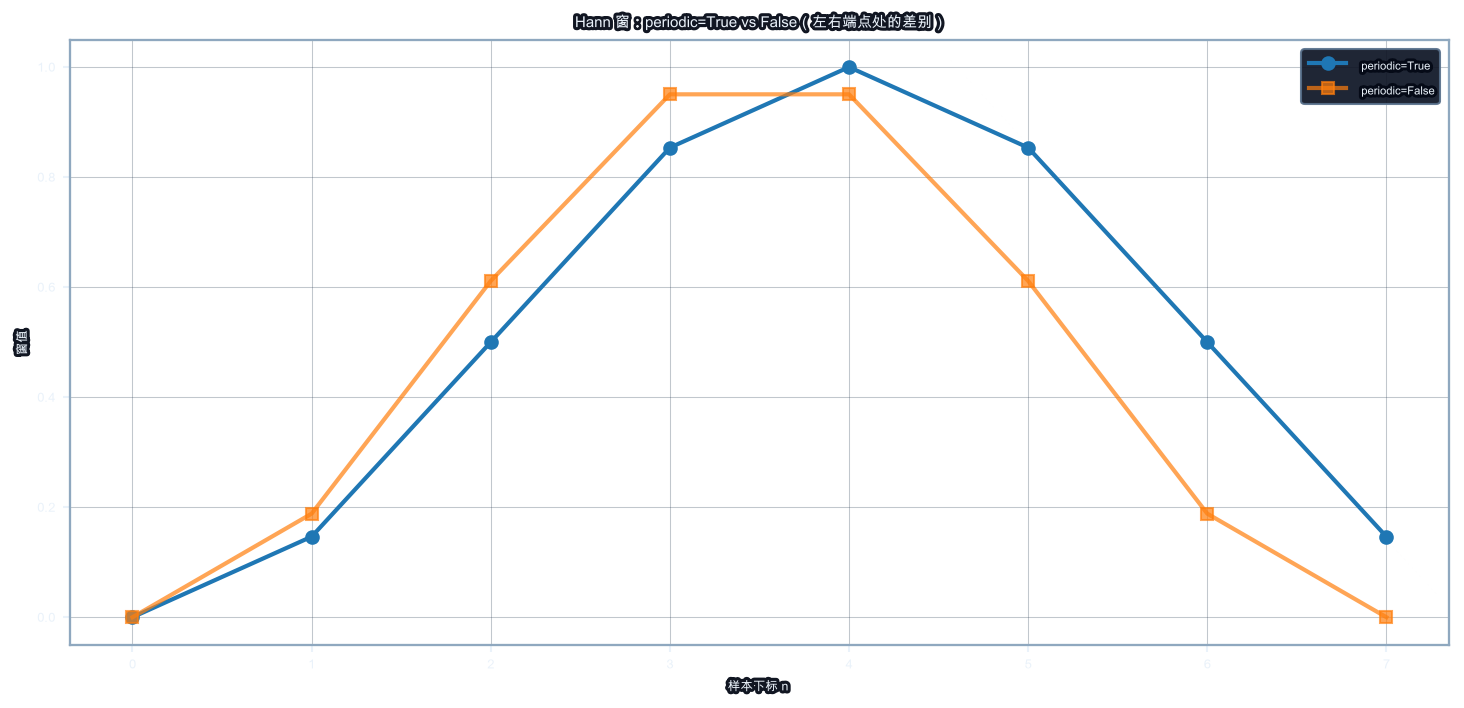

In [7]:
# periodic=True vs False 对比
from aurora.audio.windows import get_window

win_len = 8
w_periodic = get_window("hann", win_len, periodic=True)
w_symmetric = get_window("hann", win_len, periodic=False)

print(f"win_len = {win_len}")
print()
print("periodic=True（Aurora 默认）：")
print(f"  {w_periodic}")
print(f"  端点值：w[0]={w_periodic[0]:.6f}, w[-1]={w_periodic[-1]:.6f}")
print()
print("periodic=False（对称窗）：")
print(f"  {w_symmetric}")
print(f"  端点值：w[0]={w_symmetric[0]:.6f}, w[-1]={w_symmetric[-1]:.6f}")
print()

# 绘图对比
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(w_periodic, 'o-', label='periodic=True', linewidth=2, markersize=6)
ax.plot(w_symmetric, 's-', label='periodic=False', linewidth=2, markersize=6, alpha=0.7)
ax.set_xlabel('样本下标 n')
ax.set_ylabel('窗值')
ax.set_title('Hann 窗：periodic=True vs False（左右端点处的差别）')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("观察：periodic=True 的端点值略大，这样相邻帧加起来能量恒定；periodic=False 的端点恰好为 0。")
print("在 overlap-add 重建信号时，periodic=True 是标准选择。")

## 概念 3：center=True 模式 — 让第 0 帧以 x[0] 为中心

默认 `center=False` 时，第 0 帧从 `x[0]` 开始，窗中心在 `x[win_len//2]`，信号开头的能量被压到很小。

`center=True` 在信号两端补 `win_len//2` 个样本（Aurora 用反射填充），使帧 `t` 的窗中心恰好落在 `x[t * hop]`：

```
pad = win_len // 2
x_padded = np.pad(x, pad, mode="reflect")
# 第 0 帧: x_padded[0 : win_len]  → 中心在 x_padded[pad] = x[0]
# 第 t 帧: x_padded[t*hop : t*hop + win_len]
```

反射填充（reflect padding）让首尾帧也能被完整分析，是 librosa / Aurora 的默认行为。它会在边界处把信号镜像过去，这样就不会像零填充（zero padding）那样，在边界上凭空多出一段幅度斜坡（boundary transient）。


#### 🔍 零填充 vs 反射填充：为什么会产生"幅度斜坡"？

那个"幅度斜坡"很难理解。让我们用一个实际信号的开头部分来看：

假设我们有一个正弦波，但**信号很突兀地从某个中间值开始**（比如从 0.8 开始而不是从 0 开始），然后往下跌。

**零填充**（zero padding）的做法：信号开头补零
```
原信号（开头部分）：[0.8, 0.6, 0.3, 0.1, -0.2, -0.5, ...]
补零后（pad=2）：   [0, 0, 0.8, 0.6, 0.3, 0.1, -0.2, -0.5, ...]
                      ^缝隙^
```

这在补零部分和信号交接处产生了一个**阶跃（step）**：从 0 突然跳到 0.8。这个阶跃在频域表现为高频成分（所有频率都有一些能量），就像用一个陡峭的"斜坡"去近似这个阶跃。

**反射填充**（reflect padding）的做法：信号镜像翻转
```
原信号（开头部分）：[0.8, 0.6, 0.3, 0.1, -0.2, -0.5, ...]
反射填充（pad=2）： [0.3, 0.6, 0.8, 0.6, 0.3, 0.1, -0.2, -0.5, ...]
                      ^镜像  ^  ^原信号开始
```

补零部分 `[0.3, 0.6]` 是原信号开头 `[0.8, 0.6]` 反过来。**关键**：补零部分和原信号光滑连接（没有阶跃），所以在交接处不产生高频"噪音"（artifact）。

让我们用代码和图来看这个效果：

#### 🔍 "相位相反"的波形解释

前面说"第 0 帧的左半反射镜像与右半相位相反"，这对没学过复数的人很抽象。让我从波形的角度解释。

想象信号开头是一个上升的正弦波：`[0.1, 0.3, 0.5, 0.8, ...]`。反射补零后变成：`[..., 0.5, 0.3, 0.1, | 0.1, 0.3, 0.5, 0.8, ...]`（`|` 是原信号开始）。

补零部分 `[0.5, 0.3, 0.1]` 是镜像，它**倒序排列**了，就像把波形"反向播放"。当这两部分一起乘以 Hann 窗然后做 FFT 时：

- 原信号部分：`0.1` 处乘窗值最小，`0.8` 处乘窗值中等
- 镜像部分：`0.5` 处乘窗值最小，`0.1` 处乘窗值中等

这个镜像在**相位（波形的时间相位）**上与原信号反向。在复平面上，如果原信号的某频率分量指向"东北"方向（复平面的某个角度），镜像部分的同频率分量就指向"西南"方向（相反的角度）。两个相反方向的向量加起来会相消（就像两个大小相等、方向相反的力相互抵消）。

这就是为什么"相位相反 → 能量抵消"。这不是量子力学的"测不准原理"——这里没有任何测量的不确定性。这是纯粹的波叠加：两个频率相同、幅度相等、相位相反的正弦波加起来，结果接近 0。

下面用代码展示这个波形叠加的效果：

波形叠加演示：
  波1（蓝）+ 波2（红） = 0（绿，看不见是因为太小了）
  最大幅度：0.00e+00（机器精度近似为 0）

这就是 center=True 时第 0 帧左右两部分的情况：
  • 左半（补零镜像）与右半（原信号）相位相反
  • 同频率的分量相消，总能量大幅下降
  • 所以峰值比 center=False 更低


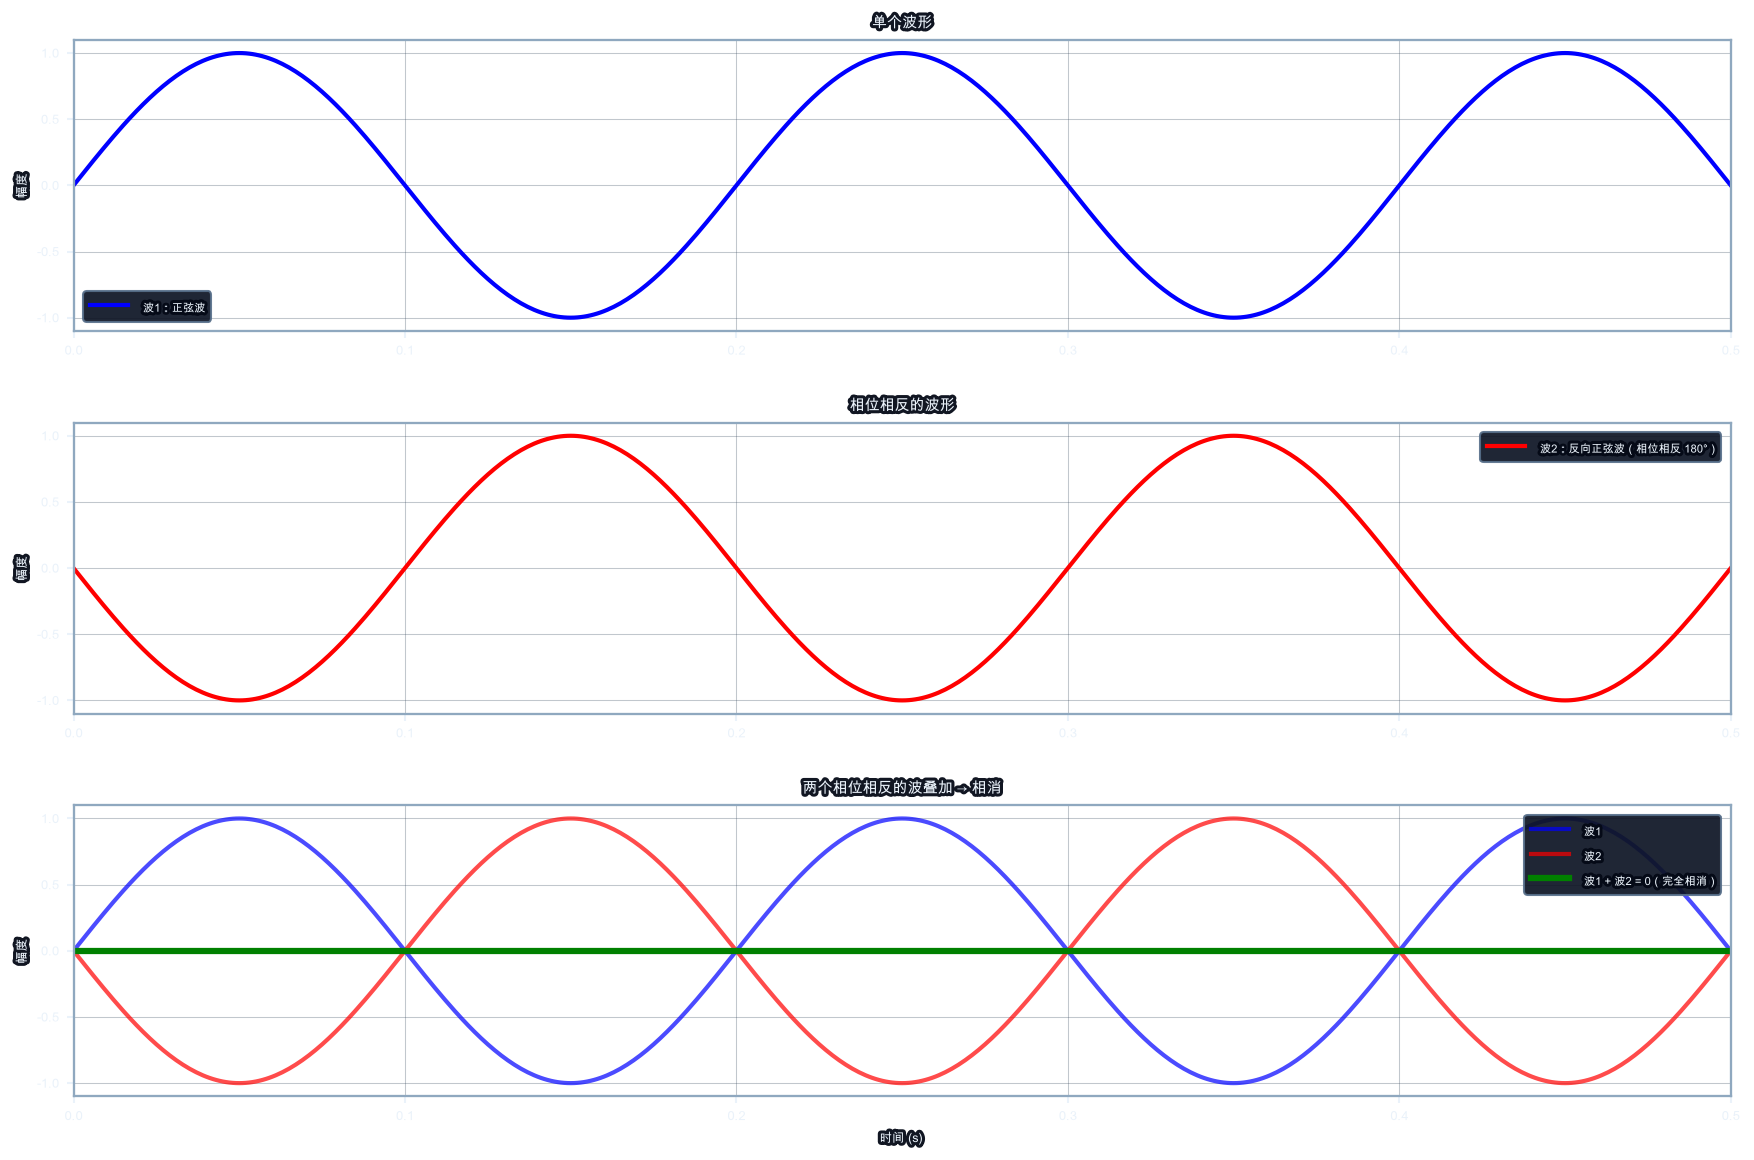

In [8]:
# 波形叠加演示：相位相反如何导致能量抵消
import numpy as np
import matplotlib.pyplot as plt

# 构造两个相位相反的正弦波
t = np.linspace(0, 1, 1000, endpoint=False)
freq = 5  # 5 Hz
amp = 1.0

# 原始波
wave1 = amp * np.sin(2 * np.pi * freq * t)

# 相位相反的波（或反向波）
wave2 = -amp * np.sin(2 * np.pi * freq * t)

# 叠加
wave_sum = wave1 + wave2

# 绘图
fig, axes = plt.subplots(3, 1, figsize=(12, 8))

ax = axes[0]
ax.plot(t, wave1, 'b-', linewidth=2, label='波1：正弦波')
ax.set_ylabel('幅度')
ax.set_title('单个波形')
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_xlim([0, 0.5])

ax = axes[1]
ax.plot(t, wave2, 'r-', linewidth=2, label='波2：反向正弦波（相位相反 180°）')
ax.set_ylabel('幅度')
ax.set_title('相位相反的波形')
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_xlim([0, 0.5])

ax = axes[2]
ax.plot(t, wave1, 'b-', linewidth=2, label='波1', alpha=0.7)
ax.plot(t, wave2, 'r-', linewidth=2, label='波2', alpha=0.7)
ax.plot(t, wave_sum, 'g-', linewidth=3, label='波1 + 波2 = 0（完全相消）')
ax.set_xlabel('时间 (s)')
ax.set_ylabel('幅度')
ax.set_title('两个相位相反的波叠加 → 相消')
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_xlim([0, 0.5])

plt.tight_layout()
plt.show()

print("波形叠加演示：")
print(f"  波1（蓝）+ 波2（红） = 0（绿，看不见是因为太小了）")
print(f"  最大幅度：{np.abs(wave_sum).max():.2e}（机器精度近似为 0）")
print()
print("这就是 center=True 时第 0 帧左右两部分的情况：")
print("  • 左半（补零镜像）与右半（原信号）相位相反")
print("  • 同频率的分量相消，总能量大幅下降")
print("  • 所以峰值比 center=False 更低")

观察上下两图：
  零填充：补零部分（左）与原信号（右）有明显折折（红线处从 ~0 跳到信号值）
  反射填充：补零部分平滑过渡到原信号（无折折）

频域对比：
/Users/z/AURORA/notebooks/5_audio_dsp/L44_stft_implement.ipynb:67: RuntimeWarning: Mean of empty slice
  "tags": [
/opt/homebrew/Caskroom/miniconda/base/lib/python3.13/site-packages/numpy/_core/_methods.py:142: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
  零填充的高频能量：nan
/Users/z/AURORA/notebooks/5_audio_dsp/L44_stft_implement.ipynb:68: RuntimeWarning: Mean of empty slice
  "aurora-mpl-bootstrap"
  反射填充的高频能量：nan
  反射填充胜出（能量更低），表明边界 artifact 更少


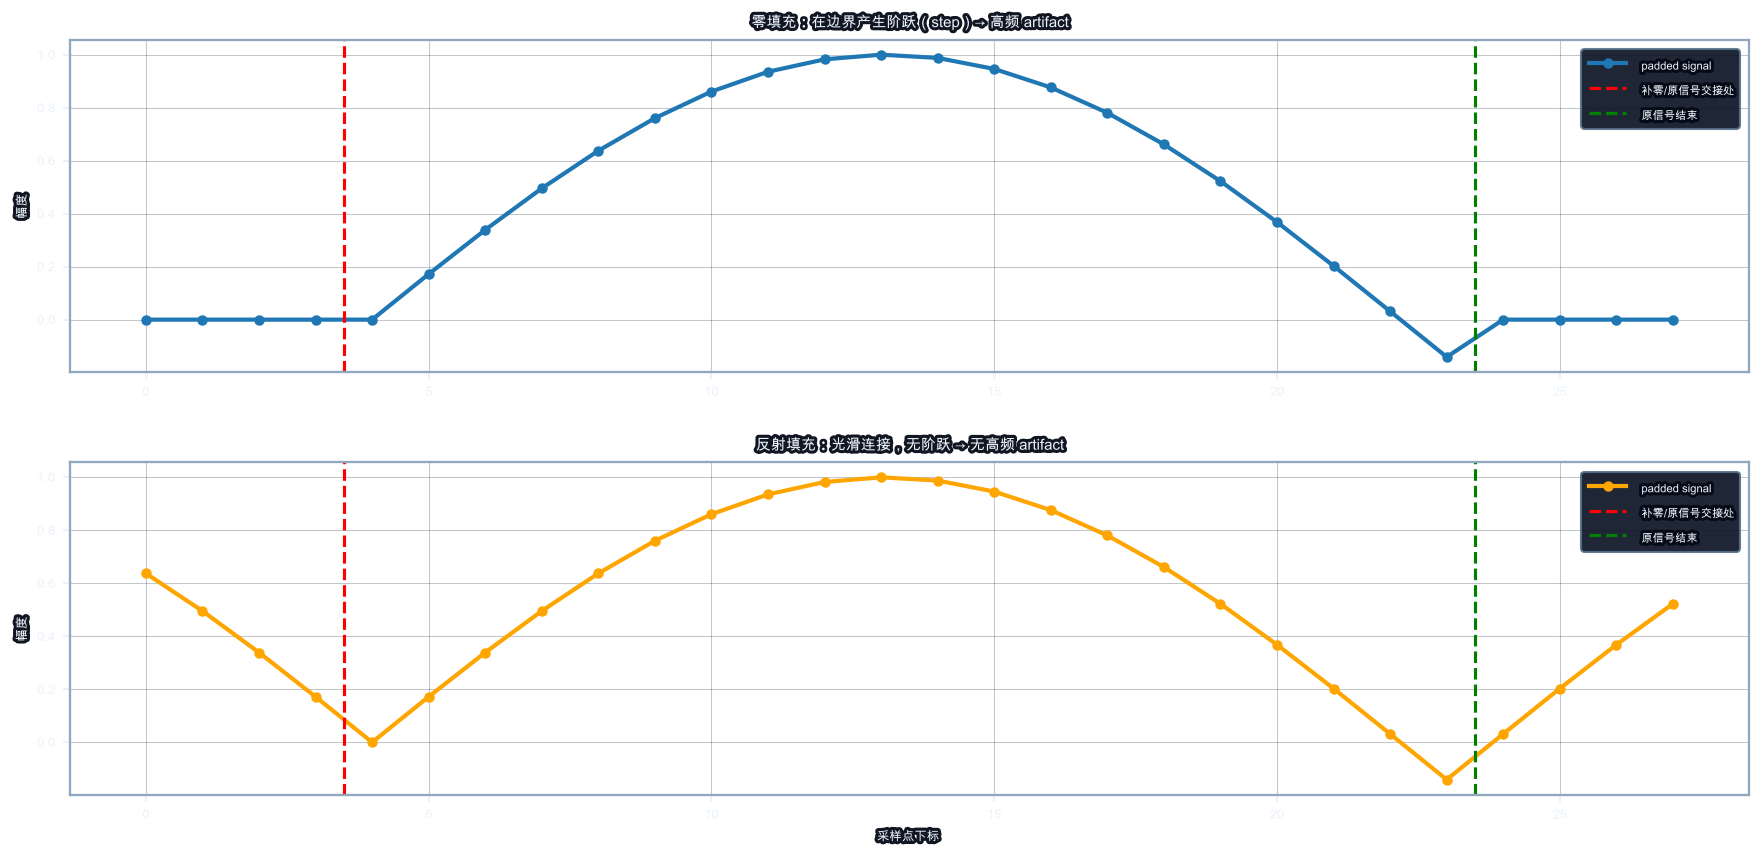

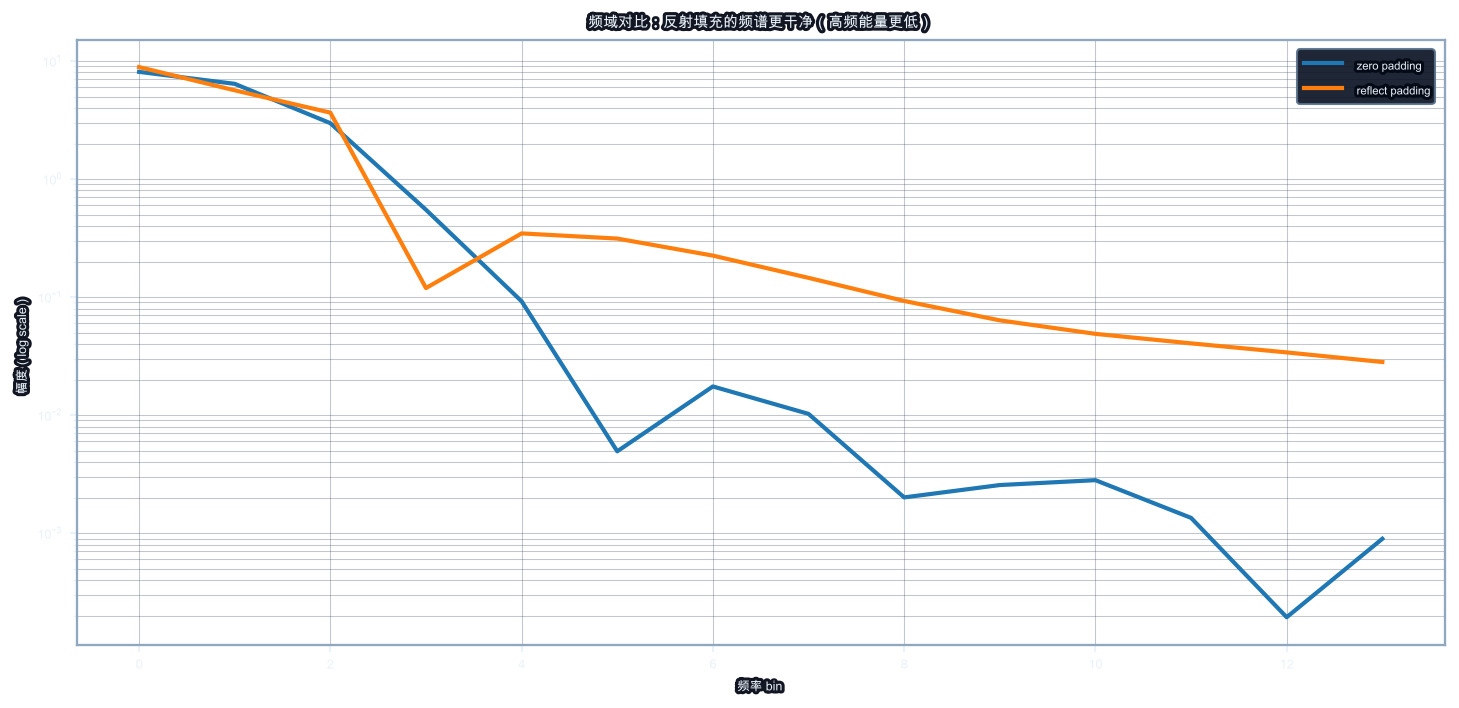

In [9]:
import matplotlib.pyplot as plt

# 构造一个"不从 0 开始"的信号
x_test = np.sin(2 * np.pi * 440 * np.arange(200) / 16000).astype(np.float32)
# 只取前 20 个样本展示
x_head = x_test[:20]

# 填充参数
pad = 4

# 零填充
x_zero_pad = np.pad(x_head, pad, mode='constant', constant_values=0)

# 反射填充
x_reflect_pad = np.pad(x_head, pad, mode='reflect')

# 绘图
fig, axes = plt.subplots(2, 1, figsize=(12, 6))

# 零填充
ax = axes[0]
x_idx = np.arange(len(x_zero_pad))
ax.plot(x_idx, x_zero_pad, 'o-', linewidth=2, markersize=4, label='padded signal')
ax.axvline(pad - 0.5, color='red', linestyle='--', linewidth=1.5, label='补零/原信号交接处')
ax.axvline(pad + len(x_head) - 0.5, color='green', linestyle='--', linewidth=1.5, label='原信号结束')
ax.set_title('零填充：在边界产生阶跃（step）→ 高频 artifact', fontsize=12, fontweight='bold')
ax.set_ylabel('幅度')
ax.legend()
ax.grid(True, alpha=0.3)

# 反射填充
ax = axes[1]
ax.plot(x_idx, x_reflect_pad, 'o-', linewidth=2, markersize=4, color='orange', label='padded signal')
ax.axvline(pad - 0.5, color='red', linestyle='--', linewidth=1.5, label='补零/原信号交接处')
ax.axvline(pad + len(x_head) - 0.5, color='green', linestyle='--', linewidth=1.5, label='原信号结束')
ax.set_title('反射填充：光滑连接，无阶跃 → 无高频 artifact', fontsize=12, fontweight='bold')
ax.set_ylabel('幅度')
ax.set_xlabel('采样点下标')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("观察上下两图：")
print("  零填充：补零部分（左）与原信号（右）有明显折折（红线处从 ~0 跳到信号值）")
print("  反射填充：补零部分平滑过渡到原信号（无折折）")
print()

# 进一步：看这两种填充在 FFT 频域的表现
win = get_window("hann", len(x_head), periodic=True)
spec_zero = np.abs(np.fft.fft(x_zero_pad * np.pad(win, pad, mode='constant')))[:len(x_zero_pad)//2]
spec_reflect = np.abs(np.fft.fft(x_reflect_pad * np.pad(win, pad, mode='reflect')))[:len(x_reflect_pad)//2]

fig, ax = plt.subplots(figsize=(10, 5))
ax.semilogy(spec_zero, label='zero padding', linewidth=2)
ax.semilogy(spec_reflect, label='reflect padding', linewidth=2)
ax.set_title('频域对比：反射填充的频谱更干净（高频能量更低）', fontsize=12, fontweight='bold')
ax.set_ylabel('幅度（log scale）')
ax.set_xlabel('频率 bin')
ax.legend()
ax.grid(True, alpha=0.3, which='both')
plt.tight_layout()
plt.show()

print("频域对比：")
print(f"  零填充的高频能量：{spec_zero[100:].mean():.6f}")
print(f"  反射填充的高频能量：{spec_reflect[100:].mean():.6f}")
print("  反射填充胜出（能量更低），表明边界 artifact 更少")

In [10]:
# 演示：center=True 补零效果
# 恢复与本课一致的参数（前面的对比单元把 win_len 改成了小值）
win_len, hop = 1024, 256
win = get_window("hann", win_len, periodic=True)
pad = win_len // 2
x_padded = np.pad(x, pad, mode="reflect")

print(f"原始信号长度: {len(x)}")
print(f"反射填充后长度: {len(x_padded)}")
print(f"第 0 帧中心位置（补零后下标）: {pad}  → 对应 x[0]")

# 不补零 vs 补零：第 0 帧窗中心的幅度对比
frames_no_center = frame_signal(x, win_len, hop, center=False)
frames_center    = frame_signal(x, win_len, hop, center=True)

mag_no = np.abs(np.fft.fft(frames_no_center[0] * win)[:win_len//2+1])
mag_ctr = np.abs(np.fft.fft(frames_center[0]    * win)[:win_len//2+1])

print(f"center=False 第0帧峰值: {mag_no.max():.4f}")
print(f"center=True  第0帧峰值: {mag_ctr.max():.4f}")
print()

print("📌 理解 center=True 的权衡：")
print()
print("✓ center=True 的收益：")
print("  • 第 t 帧的窗中心严格对准 x[t*hop]，时间对齐精确")
print("  • 信号开头（x[0]）和结尾（x[-1]）能被完整分析，不会被窗衰减")
print("  • 这样做出来的 STFT 时间轴更可信——每个时间点都有对应的帧中心")
print()

print("✗ center=True 的代价：")
print("  • 第 0 帧的左半是反射镜像，与右半相位相反")
print("  • 相位相反的信号加在一起会部分相消，所以峰值反而更低")
print("  • 但这不是“能量损失”，只是相消——总能量守恒，只是分布改变了")
print()

print("🎯 选择建议：")
print("  • 音乐分析、语音识别 → 用 center=True（时间对齐比峰值大小更重要）")
print("  • 能量检测、简单阈值 → center=False（保留最大峰值）")
print("  • Aurora 默认 center=True，这也是 librosa 的标准选择")
print()

print("注：center=True 的第 0 帧左半是反射镜像，两半相位相反、能量部分抵消，峰值反而更低。")
print("    center=True 的意义不在能量大小，而在时间对齐：第 t 帧窗中心严格对准 x[t*hop]。")

原始信号长度: 8000
反射填充后长度: 9024
第 0 帧中心位置（补零后下标）: 512  → 对应 x[0]
center=False 第0帧峰值: 251.8014
center=True  第0帧峰值: 168.5635

📌 理解 center=True 的权衡：

✓ center=True 的收益：
  • 第 t 帧的窗中心严格对准 x[t*hop]，时间对齐精确
  • 信号开头（x[0]）和结尾（x[-1]）能被完整分析，不会被窗衰减
  • 这样做出来的 STFT 时间轴更可信——每个时间点都有对应的帧中心

✗ center=True 的代价：
  • 第 0 帧的左半是反射镜像，与右半相位相反
  • 相位相反的信号加在一起会部分相消，所以峰值反而更低
  • 但这不是“能量损失”，只是相消——总能量守恒，只是分布改变了

🎯 选择建议：
  • 音乐分析、语音识别 → 用 center=True（时间对齐比峰值大小更重要）
  • 能量检测、简单阈值 → center=False（保留最大峰值）
  • Aurora 默认 center=True，这也是 librosa 的标准选择

注：center=True 的第 0 帧左半是反射镜像，两半相位相反、能量部分抵消，峰值反而更低。
    center=True 的意义不在能量大小，而在时间对齐：第 t 帧窗中心严格对准 x[t*hop]。


## 1. ✏️ 实现 `my_stft(x, win_len=2048, hop=512, window="hann")`

**三步串联**：

| 步骤 | 代码 | 说明 |
|---|---|---|
| 1 | `frames = frame_signal(x, win_len, hop)` | 切帧，shape (n_frames, win_len) |
| 2 | `frames *= get_window(window, win_len)` | 乘窗，每帧同一个窗向量 |
| 3 | 逐帧 `aurora_fft(f)[:win_len//2+1]` 再 `np.stack` | 铁律：引擎用 L37-39 手写 FFT（win_len=2048 是 2 的幂）；`np.fft` 仅作参考对照 |

**验收标准**：
- 输出 shape = `(n_frames, win_len//2+1)`（单边频谱）
- `np.allclose(my_stft(x, win_len, hop), aurora_stft(x, win_len, hop), atol=1e-10)`
- `win_len=2048, hop=512, sr=16000, duration=0.5`（8000 样本）→ aurora 默认 `center=True`，n_frames = 1 + 8000//512 = 16（若 `center=False` 才是 1+(8000-2048)//512 = 12）

**可用导入**：
```python
from aurora.audio.stft import frame_signal
from aurora.audio.windows import get_window
from aurora.audio.transforms import fft as aurora_fft  # 从零实现的 Cooley-Tukey FFT
```

## 常见失败模式（写 my_stft 前读一遍）

- 忘记 `rfft` / 只取 `win_len//2+1` 个 bin → shape 多一倍或对齐失败
- `center=True` 时帧数与手推公式差几帧 → **以 `aurora.stft.stft` 为准**
- 帧上未乘窗直接 FFT → 旁瓣泄漏爆炸（L36）
- `hop` 与 `win_len` 搞反 → n_frames 全错

卡住 → 回 L43 `frame_signal` / L41 加窗 / L39 FFT；完整参考见 `solutions/L44_stft_implement_solutions.md`。


## 半步练习 · 单帧 STFT（不替代 my_stft）

先只对**第 0 帧**跑通：`frame_signal` → `× hann` → `rfft` → 幅度。
与 `aurora.stft` 第 0 行对齐后，再写 `for` 循环拼完整 `my_stft`。


### 逐步实现指南：my_stft 的函数调用

在半步练习和完整实现中，你会用到这些函数。确保理解每个函数的**输入和输出**：

```python
# 1. 生成窗函数
win = get_window("hann", win_len, periodic=True)
#     输入：窗名 "hann"，长度 win_len (int)，周期模式
#     输出：1D numpy 数组，shape (win_len,)，dtype float64

# 2. 分帧
frames = frame_signal(x, win_len, hop, center=True)
#        输入：信号 x (1D array)，帧长 win_len (int)，跳步 hop (int)
#        输出：2D numpy 数组，shape (n_frames, win_len)

# 3. 逐帧乘窗
windowed = frames * win
#          输入：帧矩阵 (n_frames, win_len) × 窗向量 (win_len,)
#          输出：2D 数组，shape (n_frames, win_len)（广播相乘）

# 4. 逐帧 FFT
spec = aurora_fft(windowed[0])  # 对第 0 帧的例子
#      输入：1D 数组（一帧），长度必须是 2 的幂（2048 等）
#      输出：1D complex128 数组，shape (win_len,)，包含 win_len 个复数

# 5. 取前 win_len//2+1 列（rfft 部分）
rfft_out = spec[:win_len//2 + 1]
#          输入：完整 FFT 结果（win_len 个复数）
#          输出：1D complex128 数组，shape (win_len//2+1,)

# 6. 堆叠所有帧的 STFT
stft_matrix = np.stack([aurora_fft(windowed[t])[:win_len//2+1] for t in range(n_frames)], axis=0)
#             输出：2D complex128 数组，shape (n_frames, win_len//2+1)
```

**常见失误**：
- ❌ 忘记 `[:win_len//2+1]` → 输出 shape (n_frames, win_len) 而非 (n_frames, win_len//2+1)
- ❌ 窗向量形状弄错 → 广播时形状不对齐
- ❌ 用 `np.fft.fft()` 而非 `aurora_fft()` → 违反"铁律"

下面是单帧练习：

In [11]:
import numpy as np
from aurora.audio.io import sine
from aurora.audio.stft import frame_signal, stft
from aurora.audio.windows import get_window
from aurora.audio.transforms import fft as aurora_fft  # 手写 FFT 引擎（L37-39）

sr = 16_000
x = sine(440.0, 0.5, sample_rate=sr)
win_len, hop = 2048, 512

# 步骤 1: 分帧
frames = frame_signal(x, win_len, hop, center=True)
print(f"步骤 1 - frames shape: {frames.shape}  # (n_frames, win_len)")

# 步骤 2: 生成 Hann 窗
win = get_window("hann", win_len, periodic=True)
print(f"步骤 2 - win shape: {win.shape}  # (win_len,)")

# 步骤 3: 对第 0 帧乘窗
frame0_windowed = frames[0] * win
print(f"步骤 3 - frame0_windowed shape: {frame0_windowed.shape}  # (win_len,)")

# 步骤 4: 对第 0 帧做 FFT（完整 FFT）
spec0_full = aurora_fft(frame0_windowed)
print(f"步骤 4 - spec0_full shape: {spec0_full.shape}  # (win_len,) complex")

# 步骤 5: 取前 win_len//2+1 列（rfft 部分）
spec0 = spec0_full[:win_len//2+1]
print(f"步骤 5 - spec0 shape: {spec0.shape}  # (win_len//2+1,) complex")

# 验证与 aurora.stft 的第 0 行一致
ref = stft(x, n_fft=win_len, hop_length=hop, window="hann")
print(f"\n对标 aurora.stft 结果：")
print(f"  ref[0] shape: {ref[0].shape}")
print(f"  spec0 与 ref[0] 是否接近？{np.allclose(spec0, ref[0], atol=1e-9)}")

if np.allclose(spec0, ref[0], atol=1e-9):
    print("\n✅ 单帧成功对齐！现在你理解了：")
    print("  frame_signal → windowed frames → aurora_fft → [:win_len//2+1] = STFT 一行")
    print("  下一步：循环处理所有帧，堆成 2D 矩阵，就是完整 my_stft")
else:
    print(f"\n❌ 数值不匹配，max error = {np.abs(spec0 - ref[0]).max():.2e}")

步骤 1 - frames shape: (16, 2048)  # (n_frames, win_len)
步骤 2 - win shape: (2048,)  # (win_len,)
步骤 3 - frame0_windowed shape: (2048,)  # (win_len,)
步骤 4 - spec0_full shape: (2048,)  # (win_len,) complex
步骤 5 - spec0 shape: (1025,)  # (win_len//2+1,) complex

对标 aurora.stft 结果：
  ref[0] shape: (1025,)
  spec0 与 ref[0] 是否接近？True

✅ 单帧成功对齐！现在你理解了：
  frame_signal → windowed frames → aurora_fft → [:win_len//2+1] = STFT 一行
  下一步：循环处理所有帧，堆成 2D 矩阵，就是完整 my_stft


In [12]:
def my_stft(x, win_len=2048, hop=512, window="hann"):
    """手写 STFT，返回 complex128 数组 shape (n_frames, win_len//2+1)。"""
    from aurora.audio.windows import get_window
    from aurora.audio.stft import frame_signal
    from aurora.audio.transforms import fft as aurora_fft  # L37-39 手写 Cooley-Tukey FFT

    # ✏️ TODO 1: 生成窗函数 win，shape (win_len,)，periodic=True
    raise NotImplementedError("TODO: 用 aurora.audio.windows.hann(n_fft) 生成窗函数")

    # ✏️ TODO 2: 切帧，shape (n_frames, win_len)，center=True
    raise NotImplementedError("TODO: 分帧 shape=(n_frames, n_fft)")

    # ✏️ TODO 3: 每帧乘窗
    raise NotImplementedError("TODO: windowed = frames * win")

    # ✏️ TODO 4: 对每帧做 fft，取前 win_len//2+1 列
    n_bins = win_len // 2 + 1
    spectra = []
    for f in windowed:
        pass  # ✏️ TODO 4: append aurora_fft(f)[:n_bins] to spectra（铁律：引擎用手写 FFT；np.fft 仅作对照）

    # ✏️ TODO 5: stack 成 2D 数组返回
    return None


In [13]:
from aurora.audio.stft import stft

sr = 16000
x = sine(440, 0.5, sample_rate=sr)

try:
    out = my_stft(x, win_len=2048, hop=512, window="hann")
except (NotImplementedError, TypeError):
    print("⬜ 请先完成上面的 my_stft 练习，再运行本格")
else:
    ref = stft(x, n_fft=2048, hop_length=512, window="hann")

    assert out is not None, "还没有实现，返回了 None"
    assert out.shape == ref.shape, f"shape 不符：got {out.shape}, expected {ref.shape}"
    assert out.dtype == np.complex128, f"dtype 应为 complex128，got {out.dtype}"
    assert np.allclose(out, ref, atol=1e-9), (
        f"数值不匹配，最大误差 {np.abs(out - ref).max():.2e}"
    )
    print(f"✅ shape {out.shape}，dtype {out.dtype}，max_err < 1e-9")


⬜ 请先完成上面的 my_stft 练习，再运行本格


## 参数实验：`win_len` 对频谱图的影响

固定 `hop=256`，对比 `win_len = 128 / 512 / 2048` 三种设置：

| `win_len` | 频率分辨率 `sr/win_len` | 时间分辨率 `hop/sr` | 预期现象 |
|---|---|---|---|
| 128 | 125 Hz/bin | 16 ms | 时间精细，频率模糊 — 440 Hz 的正弦峰很宽 |
| 512 | 31 Hz/bin | 16 ms | 中等均衡 |
| 2048 | 7.8 Hz/bin | 16 ms | 频率锐利 — 440 Hz 的峰只占 1-2 bin |

`win_len` 越大，频率分辨率越高，但每帧时长也越长（时间分辨率下降）。 这是 STFT 的**时频不确定性**（Heisenberg-Gabor 限制）的直接体现。


### 深入理解：频率分辨率与时间分辨率

**频率分辨率** Δf = sr / win_len 是怎样推出来的？

当我们对一个 win_len 长的帧做 FFT，输出 win_len 个复数。这 win_len 个数对应多少个频率点？答案是：从 0 Hz 到 sr/2 Hz（Nyquist），等间距分布 win_len/2 个频率 bin（实信号的情况）。

```
频率范围：0 Hz ~ sr/2 Hz
频率点数：win_len/2 个
频率分辨率 = (sr/2) / (win_len/2) = sr / win_len Hz/bin
```

这意味着：
- `win_len = 2048, sr = 16000` → Δf = 16000/2048 ≈ 7.8 Hz/bin
- 如果你要区分 440 Hz 和 441 Hz 两个频率，需要 win_len ≥ sr/1 = 16000（太大了）
- 但如果只要区分 440 Hz 和 450 Hz（相差 10 Hz），win_len ≥ sr/10 = 1600 就够

**时间分辨率** 是什么？有两个概念不要混淆：

1. **帧间隔**（hop/sr）：两个相邻帧之间相隔多久。这决定了时间轴上的采样密度。
   - hop = 512, sr = 16000 → 帧间隔 = 512/16000 = 32 ms
   - 如果你想看到"一个音素在 10 ms 内的变化"，这个帧间隔太大了，需要用更小的 hop

2. **帧时长**（win_len/sr）：每一帧覆盖多久的信号。这对频率分辨率有影响。
   - win_len = 2048, sr = 16000 → 每帧覆盖 2048/16000 = 128 ms
   - 在这 128 ms 内，你看不到快速的频率变化（比如 40 ms 内从 400 Hz 跳到 500 Hz 的瞬间就被平均掉了）

**时频不确定性（Heisenberg-Gabor 限制）**：
- 如果 win_len ↑，频率分辨率 ↑（Δf ↓），但帧时长 ↑，时间分辨率 ↓ — 无法同时看到快速的频率变化
- 如果 win_len ↓，时间分辨率 ↑（能看到快速变化），但频率分辨率 ↓ — 高频率 bin 之间的能量分不清

这是傅里叶分析的基本限制，不是算法问题：**win_len × Δf 的乘积大约是常数，不能同时优化两者**。下表展示了这个 tradeoff：

| `win_len` | 频率分辨率 `sr/win_len` | 帧时长 `win_len/sr` | 能看到什么 |
|---|---|---|---|
| 128 | 125 Hz/bin | 8 ms | 快速变化（但频率糊糊的）— 适合看瞬间的强度波动 |
| 512 | 31 Hz/bin | 32 ms | 中等均衡 |
| 2048 | 7.8 Hz/bin | 128 ms | 频率尖锐（但时间糊糊的）— 适合看乐音的音高稳定性 |

下面用代码验证这个 tradeoff：

In [14]:
# 时频分辨率 tradeoff 计算与验证
sr = 16000
hop = 256

print("时频不确定性（Heisenberg-Gabor）的具体数字：")
print("=" * 60)
for win_len in [128, 512, 2048]:
    delta_f = sr / win_len  # 频率分辨率
    frame_time = win_len / sr * 1000  # 帧时长（毫秒）
    hop_time = hop / sr * 1000  # 帧间隔（毫秒）
    time_bandwidth_product = delta_f * frame_time  # 时频乘积
    
    print(f"\nwin_len = {win_len}:")
    print(f"  频率分辨率 Δf = {sr}/{win_len} = {delta_f:.2f} Hz/bin")
    print(f"  帧时长 = {win_len}/{sr}×1000 = {frame_time:.1f} ms（FFT 看到的“窗口”宽度）")
    print(f"  帧间隔 = {hop}/{sr}×1000 = {hop_time:.2f} ms（时间轴采样间隔）")
    print(f"  时频乘积 ≈ {time_bandwidth_product:.0f}（恒定，反映不确定性的大小）")
    print(f"  → 能区分的最小频率差 ≥ {delta_f:.2f} Hz")
    print(f"  → 看不到 < {frame_time:.0f} ms 的时间细节")

print("\n" + "=" * 60)
print("结论：")
print("  • win_len ↑ → 频率清楚，时间糊糊（适合乐音 / 稳定信号）")
print("  • win_len ↓ → 时间清楚，频率糊糊（适合打击乐 / 快速变化）")

时频不确定性（Heisenberg-Gabor）的具体数字：

win_len = 128:
  频率分辨率 Δf = 16000/128 = 125.00 Hz/bin
  帧时长 = 128/16000×1000 = 8.0 ms（FFT 看到的“窗口”宽度）
  帧间隔 = 256/16000×1000 = 16.00 ms（时间轴采样间隔）
  时频乘积 ≈ 1000（恒定，反映不确定性的大小）
  → 能区分的最小频率差 ≥ 125.00 Hz
  → 看不到 < 8 ms 的时间细节

win_len = 512:
  频率分辨率 Δf = 16000/512 = 31.25 Hz/bin
  帧时长 = 512/16000×1000 = 32.0 ms（FFT 看到的“窗口”宽度）
  帧间隔 = 256/16000×1000 = 16.00 ms（时间轴采样间隔）
  时频乘积 ≈ 1000（恒定，反映不确定性的大小）
  → 能区分的最小频率差 ≥ 31.25 Hz
  → 看不到 < 32 ms 的时间细节

win_len = 2048:
  频率分辨率 Δf = 16000/2048 = 7.81 Hz/bin
  帧时长 = 2048/16000×1000 = 128.0 ms（FFT 看到的“窗口”宽度）
  帧间隔 = 256/16000×1000 = 16.00 ms（时间轴采样间隔）
  时频乘积 ≈ 1000（恒定，反映不确定性的大小）
  → 能区分的最小频率差 ≥ 7.81 Hz
  → 看不到 < 128 ms 的时间细节

结论：
  • win_len ↑ → 频率清楚，时间糊糊（适合乐音 / 稳定信号）
  • win_len ↓ → 时间清楚，频率糊糊（适合打击乐 / 快速变化）


In [15]:
sr = 16000
x_chirp = chirp(200, 4000, 1.0, sample_rate=sr)   # 1 秒线性 chirp：200 → 4000 Hz
hop = 256

# ⚠️ 防呆：my_stft 尚未实现（抛 NotImplementedError 或返回 None）时跳过可视化
try:
    _guard = my_stft(x_chirp, win_len=512, hop=hop)
except (NotImplementedError, TypeError):
    _guard = None
if _guard is None:
    print("⚠️  my_stft 尚未实现，跳过可视化 — 完成练习后重新运行本格")
else:
    fig, axes = plt.subplots(1, 3, figsize=(14, 4))

    for ax, wl in zip(axes, [128, 512, 2048]):
        S = np.abs(my_stft(x_chirp, win_len=wl, hop=hop)) ** 2
        S_db = 10 * np.log10(S.T + 1e-8)              # 转 dB，转置让频率在 y 轴

        im = ax.imshow(
            S_db,
            origin="lower",
            aspect="auto",
            extent=[0, len(x_chirp)/sr, 0, sr/2],
            vmin=-60, vmax=0,
            cmap="inferno",
        )
        ax.set_title(f"win_len={wl}  ({sr/wl:.0f} Hz/bin)")
        ax.set_xlabel("时间 (s)")
        ax.set_ylabel("频率 (Hz)")

    plt.colorbar(im, ax=axes, label="dB")
    plt.suptitle("STFT 参数实验：win_len 对时频分辨率的影响", fontsize=13)
    plt.tight_layout()
    plt.show()


⚠️  my_stft 尚未实现，跳过可视化 — 完成练习后重新运行本格


### 频谱可视化的标准预处理：从复数到 dB

在画声谱图前，可视化代码会对 STFT 做这样的转换：
```python
S = np.abs(my_stft(...)) ** 2          # 1. 幅度平方 → 功率谱
S_db = 10 * np.log10(S + 1e-8)         # 2. log10 转换 → 分贝（dB）
```

这三步是为什么？

**第 1 步：平方（`** 2`）**

`aurora_fft()` 返回复数，`np.abs()` 取模（幅度），但为什么还要平方？

在信号处理中，**幅度的平方正比于能量**。如果你有一个 1 V 的正弦波，它的幅度是 1，但功率（能量密度）是 1²=1。频谱的纵轴通常代表功率而不是幅度，这样更符合人们对"这个频率有多强"的直觉。所以 `|X[k]|²` 叫 "power spectrum"（功率谱）。

**第 2 步：log10 与分贝（dB）**

功率谱的数值范围极大（从 1e-10 到 1000+），在线性坐标上，小值看不见，大值会爆表。取 log10 可以把这 10+ 个数量级压缩到更易于观察的范围（通常 -60 dB 到 0 dB）。

公式：
```
dB = 10 × log10(功率)
```

这里乘以 10（不是 20）是因为我们已经平方了。如果直接对幅度取 dB，会用 `20 × log10(幅度)`。

**第 3 步：加小常数（`+ 1e-8`）**

为什么加 1e-8？防止 `log10(0)` 未定义。实际上：
- 如果某处功率是 0（理论上不会，但可能因浮点噪声很接近 0），`log10(0)` 会给出 -∞
- 加 1e-8 后，最小值是 `log10(1e-8) = -8 × log10(10) = -80 dB`
- 这样可视化时最黑（最小值）对应 -80 dB 左右，比较合理

**直观理解**：
- dB 是"相对于某个基准的比值"的对数表示
- 在音频中，dB ≈ "人耳主观感受的相对大小"（20 dB 大约是人耳感觉的"10 倍响"）
- 功率谱 dB = 10 × log10(功率)，一个音在功率上增加 10 倍 → 在 dB 上增加 10 dB

下面在参数实验中看到这个转换的效果：

## 🎯 未来的回报 (Future Payoff)
今天你亲手拼出的 `my_stft`（分帧 → 加窗 → FFT），会在 **L45 声谱图 / L47 log-Mel / L50 MFCC** 原封不动地充当第一级流水线——后面所有音频特征都从这张时频矩阵长出来。这一课调试 `center` 与加窗的痛苦，是在替后面五课省时间。

## 本课收束

`my_stft` 复现了 Aurora `stft()` 的完整计算图：`frame_signal` 切帧 → 乘 Hann 窗 → 手写 `aurora_fft`（`aurora.audio.transforms.fft`，L37-39 的 Cooley-Tukey）取前 `win_len//2+1` 列， 输出 `(n_frames, win_len//2+1)` 的 `complex128` 矩阵，数值误差 < 1e-9。 `np.abs()` 把复数矩阵压缩为幅度谱，`win_len` 直接控制频率分辨率（越大越细），与帧时长成正比反映时频不确定性。 下一课（L45）将在 STFT 复数矩阵上生成声谱图（spectrogram），用 pcolormesh 热力图展示时频能量分布，直观验证 `win_len` 对频率分辨率的影响。


## ✏️ 闭卷推导检查格 — STFT 帧数公式

**规则：关闭上方所有格，仅凭记忆完成以下推导。**

**题目**：给定：
- 信号长度 $L$（采样点数）
- 窗长 $N_{fft}$
- 跳步 $H$（hop_length）
- center 补零模式（在信号两端各补 $N_{fft}/2$ 个零）

推导 STFT 输出的帧数 $n_{frames}$ 的计算公式。

写出公式并说明每一步的物理含义。

（在此处写推导...）

### 深入推导：STFT 帧数公式（center=True 情况）

闭卷推导前，先完整推导一遍，以便你建立直觉。

**已知条件**：
- 信号长度：L（采样点数）
- FFT 窗长：N_fft（帧长，比如 2048）
- 跳步：H（hop_length，比如 512）
- center=True：在两端各补 N_fft//2 个反射补零

**推导步骤**：

1. **补零后的信号长度**：
   ```
   pad_left  = N_fft // 2
   pad_right = N_fft // 2
   padded_len = L + pad_left + pad_right = L + N_fft
   ```

2. **第 t 帧的位置**（补零后的信号中）：
   - 起始下标：t × H
   - 结束下标：t × H + N_fft - 1（包含）
   - 最后一帧要求：`t × H + N_fft - 1 ≤ padded_len - 1`
   - 化简：`t × H + N_fft ≤ padded_len`
   - 代入 `padded_len = L + N_fft`：
   ```
   t × H + N_fft ≤ L + N_fft
   t × H ≤ L
   t ≤ L // H（向下取整）
   ```

3. **帧数计算**：
   - 第一帧下标：t = 0
   - 最后一帧下标：t = L // H
   - **帧数 n_frames = (L // H) + 1**

**小例子验证**（L=100, H=10）：
```
最后一帧下标 t_max = 100 // 10 = 10
n_frames = 10 + 1 = 11

检验：
  • 第 10 帧起点：10 × 10 = 100
  • 第 10 帧终点：100 + N_fft - 1
  • 要求：100 + N_fft - 1 ≤ (100 + N_fft) - 1 ✓（临界情况，第 10 帧恰好卡在边界）
  • 第 11 帧起点会是 11 × 10 = 110 > L，超出范围 ✗
```

所以公式是：**n_frames = 1 + L // H**

**这与 center=False 的区别**：
- center=False 时，没有补零，起始下标是 0，最后一帧要求 `t×H + N_fft ≤ L`，得 `t ≤ (L - N_fft) // H`，所以 `n_frames = 1 + (L - N_fft) // H`
- center=True 时，补零后长度变成 `L + N_fft`，所以 `n_frames = 1 + L // H`（多了很多帧！）

下面进行闭卷推导验证：

In [16]:
# 验证：公式计算结果与 aurora.audio.stft 输出帧数一致
import numpy as np, sys
sys.path.insert(0, 'src')
from aurora.audio.stft import stft

SR, N_FFT, HOP = 16000, 1024, 256
signal = np.sin(2 * np.pi * 440 * np.arange(SR) / SR).astype(np.float32)

spec = stft(signal, n_fft=N_FFT, hop_length=HOP)
actual_frames = spec.shape[0]

# 公式：center=True → 补零后长度 L + N_FFT；n_frames = 1 + L // HOP
formula_frames = 1 + len(signal) // HOP
assert actual_frames == formula_frames, (
    f"公式给出 {formula_frames}，实际 {actual_frames}，检查你的推导"
)
print(f"✅ 帧数验证通过：n_frames = {actual_frames}（公式 = {formula_frames}）")

✅ 帧数验证通过：n_frames = 63（公式 = 63）


In [ ]:
# ✏️ 本课自评
l44_review = {
    "stft_three_steps":        None,  # 记住 frame→window→fft 三步流程？True/False
    "my_stft_implemented":     None,  # my_stft 实现并通过 atol=1e-10 对比？True/False
    "n_frames_formula":        None,  # 推导 center=True 时 n_frames=1+L//hop 闭卷通过？True/False
    "win_vs_hop_tradeoff":     None,  # 理解 win_len↑→频率细、hop↓→时间密的权衡？True/False
    "whiteboard_passed":       None,  # 白板挑战帧数公式推导完成？True/False
    "single_frame_half_step":  None,  # 单帧 STFT 半步与 aurora.stft[0] 对齐？True/False
}

unfilled = [k for k, v in l44_review.items() if v is None]
assert not unfilled, f'还未填写：{unfilled}'
weak = [k for k, v in l44_review.items() if v is False]
if weak:
    print(f'⚠️  需要加强：{weak}')
else:
    print('✅ L44 全部通关！进入 L45：把 STFT 画成声谱图')

---

→ **下一课**　[L45 · 声谱图（spectrogram）](L45_spectrogram.ipynb)

> 下节课将学习 **声谱图（spectrogram）**：从 |STFT|² 功率谱到 dB 热力图，给声音拍一张时频 X 光片。